# Assignment 1: Classification
Text dataset: https://www.kaggle.com/datasets/thedevastator/dbpedia-ontology-dataset  
Trained weight can be found at: https://drive.google.com/drive/folders/1C478SmoT3NFtG3xNEv9vt_f7WybIwNJp?usp=sharing

In [1]:
!rm -rf dataset
!mkdir dataset
!curl -L -o ./dataset/dbpedia-ontology-dataset.zip\
    https://www.kaggle.com/api/v1/datasets/download/thedevastator/dbpedia-ontology-dataset
!unzip ./dataset/dbpedia-ontology-dataset.zip -d dataset/
!rm ./dataset/dbpedia-ontology-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 66.2M  100 66.2M    0     0  12.5M      0  0:00:05  0:00:05 --:--:-- 17.3M
Archive:  ./dataset/dbpedia-ontology-dataset.zip
  inflating: dataset/test.csv        
  inflating: dataset/train.csv       


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import gdown
from PIL import Image

## EDA

In [3]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560000 entries, 0 to 559999
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   label    560000 non-null  int64
 1   title    560000 non-null  str  
 2   content  560000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 12.8 MB
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    70000 non-null  int64
 1   title    70000 non-null  str  
 2   content  70000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.6 MB


In [4]:
display(train_df.head())
train_df["label"].value_counts()

,label,title,content
0,0,E. D. Abbott Ltd,Abbott of Farnham E D Abbott Limited was a Br...
1,0,Schwan-Stabilo,Schwan-STABILO is a German maker of pens for ...
2,0,Q-workshop,Q-workshop is a Polish company located in Poz...
3,0,Marvell Software Solutions Israel,Marvell Software Solutions Israel known as RA...
4,0,Bergan Mercy Medical Center,Bergan Mercy Medical Center is a hospital loc...


label
0     40000
1     40000
2     40000
3     40000
4     40000
5     40000
6     40000
7     40000
8     40000
9     40000
10    40000
11    40000
12    40000
13    40000
Name: count, dtype: int64

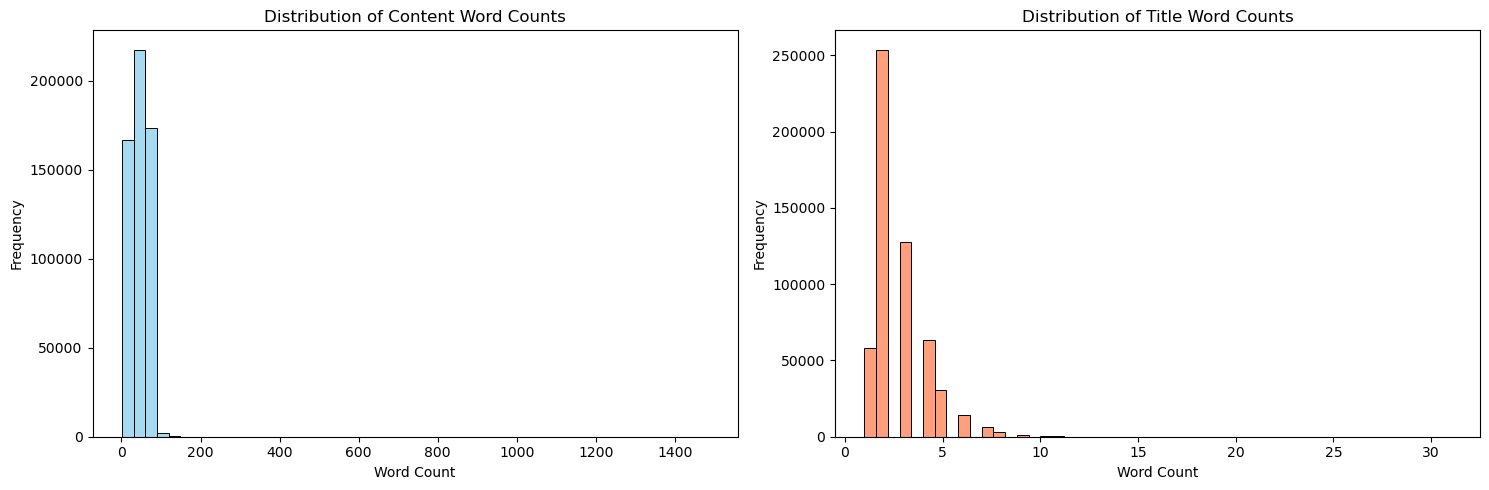

In [5]:
train_df["content_word_count"] = (
    train_df["content"].astype(str).apply(lambda x: len(x.split()))
)
train_df["title_word_count"] = (
    train_df["title"].astype(str).apply(lambda x: len(x.split()))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(train_df["content_word_count"], bins=50, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Content Word Counts")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

sns.histplot(train_df["title_word_count"], bins=50, ax=axes[1], color="coral")
axes[1].set_title("Distribution of Title Word Counts")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2405/3238042476.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="mako")


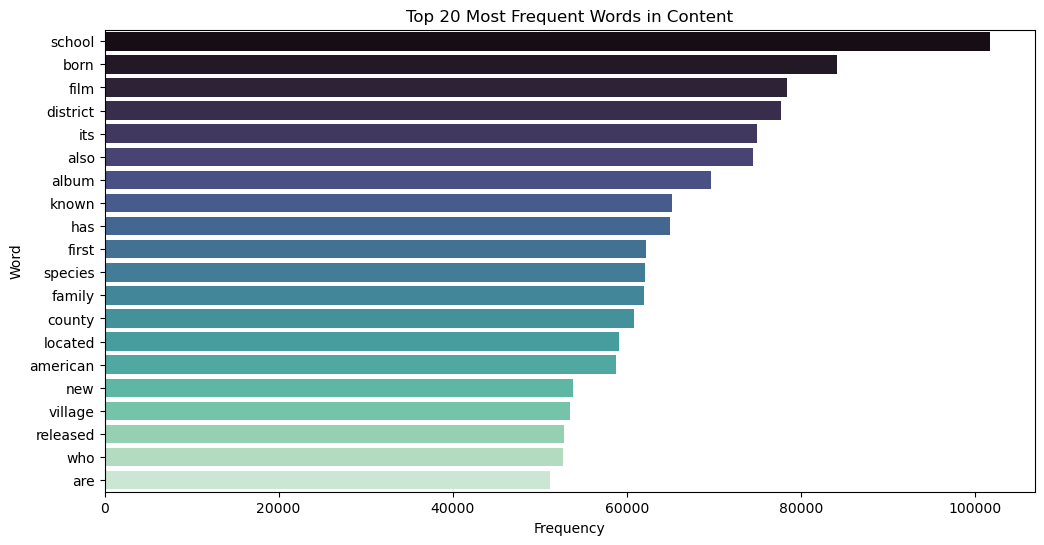

In [6]:
# Simple function to extract words and count their frequency
def get_most_frequent_words(text_series, top_n=20):
    all_text = " ".join(text_series.astype(str).tolist()).lower()
    # Simple tokenization: alphanumeric characters
    words = re.findall(r"\b[a-z]{3,}\b", all_text)
    # Exclude common english stopwords roughly (optional, using basic set)
    common_stops = {
        "the",
        "and",
        "was",
        "for",
        "that",
        "with",
        "his",
        "her",
        "this",
        "from",
    }
    words = [w for w in words if w not in common_stops]
    return Counter(words).most_common(top_n)


top_words = get_most_frequent_words(train_df["content"])

# Plot most frequent words
words, counts = zip(*top_words)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette="mako")
plt.title("Top 20 Most Frequent Words in Content")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## Prepare dataset

In [7]:
# Subsample dataset for faster experimentation if needed, else use full:
sample_size = 50000  # To speed up training in this assignment
train_sample = train_df.sample(sample_size, random_state=42).reset_index(drop=True)
test_sample = test_df.sample(int(sample_size * 0.2), random_state=42).reset_index(
    drop=True
)

# DistilBERT tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "text": text,
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(label, dtype=torch.long),
        }


train_texts = (
    train_sample["title"].fillna("") + " " + train_sample["content"].fillna("")
).values
train_labels = train_sample["label"].values
test_texts = (
    test_sample["title"].fillna("") + " " + test_sample["content"].fillna("")
).values
test_labels = test_sample["label"].values

train_dataset = TextDataset(train_texts, train_labels, tokenizer)
test_dataset = TextDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print("Data preparation complete.")

Data preparation complete.


## Model and training

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        n_layers=1,
        bidirectional=True,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            batch_first=True,
        )
        self.fc = nn.Linear(
            hidden_dim * 2 if bidirectional else hidden_dim, num_classes
        )
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        # x: [batch_size, seq_len]
        output, (hidden, cell) = self.lstm(embedded)
        # hidden: [num_layers * num_directions, batch, hidden_size]
        if self.lstm.bidirectional:
            hidden = self.dropout(
                torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
            )
        else:
            hidden = self.dropout(hidden[-1, :, :])

        return self.fc(hidden)


class DistilBertClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.distilbert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_output = self.distilbert(
            input_ids=input_ids, attention_mask=attention_mask
        )
        # pooled output
        hidden_state = bert_output[0]
        pooled_output = hidden_state[:, 0]
        output = self.drop(pooled_output)
        return self.out(output)


vocab_size = tokenizer.vocab_size
num_classes = len(np.unique(train_labels))

lstm_model = LSTMClassifier(vocab_size, 128, 256, num_classes)
distilbert_model = DistilBertClassifier(num_classes)
print("Models defined.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models defined.


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_model(model, data_loader, optimizer, criterion, device, is_bert=False):
    model.train()
    total_loss, total_correct = 0, 0
    all_preds, all_labels = [], []
    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        labels = d["label"].to(device)

        optimizer.zero_grad()
        if is_bert:
            attention_mask = d["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, dim=1)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader.dataset), accuracy_score(all_labels, all_preds)


def eval_model(model, data_loader, criterion, device, is_bert=False):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            labels = d["label"].to(device)

            if is_bert:
                attention_mask = d["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, dim=1)

            total_loss += loss.item() * len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader.dataset), accuracy_score(all_labels, all_preds)


criterion = nn.CrossEntropyLoss().to(device)


def run_experiment(model, is_bert=False, epochs=1, patience=3, save_path=None):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=2e-5 if is_bert else 1e-3)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    print(f"Training {'DistilBERT' if is_bert else 'LSTM'}...")
    total_time = 0
    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(epochs):
        start = time.time()
        train_loss, train_acc = train_model(
            model, train_loader, optimizer, criterion, device, is_bert
        )
        val_loss, val_acc = eval_model(model, test_loader, criterion, device, is_bert)
        epoch_time = time.time() - start
        total_time += epoch_time
        print(
            f"Epoch {epoch+1} | Time: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    return history, total_time

In [10]:
!mkdir weight

mkdir: cannot create directory ‘weight’: File exists


Set `TRAINING` to `True` to train the model

In [11]:
TRAINING = False

In [12]:
if TRAINING:
    # --- Execute Training ---

    # Increased to 3 epochs to be able to see the training curve
    epochs_to_run = 20

    print("--- Starting LSTM Training ---")
    lstm_history, lstm_time = run_experiment(
        lstm_model, is_bert=False, epochs=epochs_to_run, save_path="weight/lstm.pth"
    )

    print("\n--- Starting DistilBERT Training ---")
    distilbert_history, distilbert_time = run_experiment(
        distilbert_model, is_bert=True, epochs=epochs_to_run, save_path="weight/distilbert.pth"
    )
else:
    gdown.download_folder(id="1C478SmoT3NFtG3xNEv9vt_f7WybIwNJp", output="weight")
    lstm_model.load_state_dict(torch.load("weight/lstm.pth"))
    distilbert_model.load_state_dict(torch.load("weight/distilbert.pth"))

Retrieving folder contents


Processing file 1ajjHn_GNNsNBqRQotSbG0NNXCgJgRHw2 distilbert.pth
Processing file 1IFOlbbwnYUZ5_rD9BkietLa9fxsCBysi lstm.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ajjHn_GNNsNBqRQotSbG0NNXCgJgRHw2
From (redirected): https://drive.google.com/uc?id=1ajjHn_GNNsNBqRQotSbG0NNXCgJgRHw2&confirm=t&uuid=c2a16aa2-fba5-4819-bfbb-2d493a8a13bf
To: /home/minht/projects/deep_learning_assignment/source/assignment_1/text/weight/distilbert.pth
100%|██████████| 266M/266M [00:04<00:00, 62.1MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1IFOlbbwnYUZ5_rD9BkietLa9fxsCBysi
To: /home/minht/projects/deep_learning_assignment/source/assignment_1/text/weight/lstm.pth
100%|██████████| 18.8M/18.8M [00:00<00:00, 22.7MB/s]
Download completed


## Result

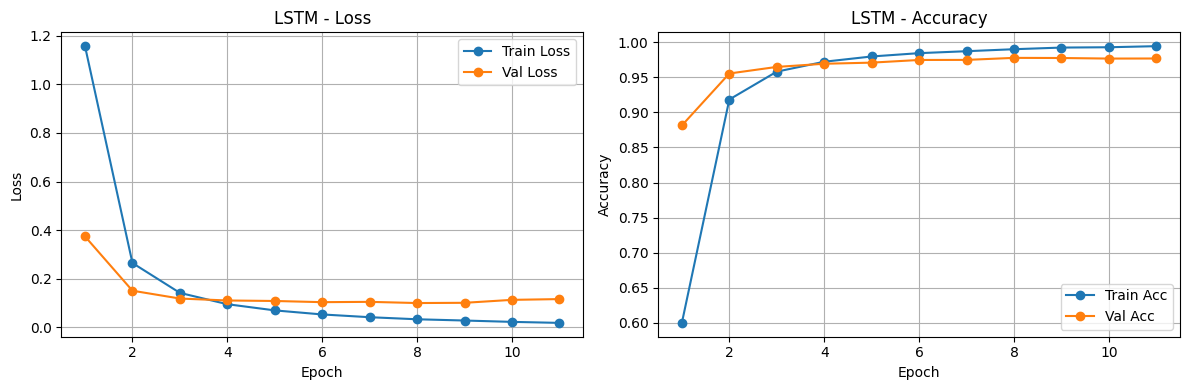

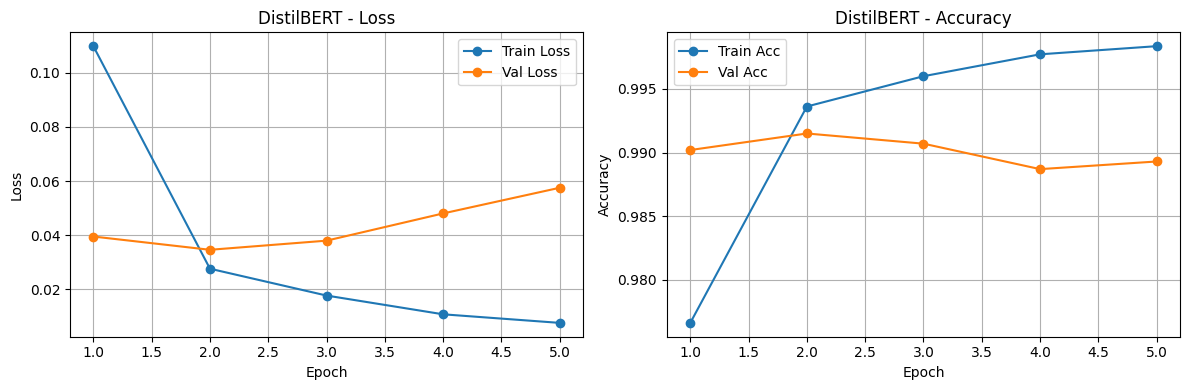

In [13]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
    ax1.set_title(f"{title} - Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Acc", marker="o")
    ax2.plot(epochs, history["val_acc"], label="Val Acc", marker="o")
    ax2.set_title(f"{title} - Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot the training curves
if TRAINING:
    plot_history(lstm_history, "LSTM")
    plot_history(distilbert_history, "DistilBERT")
else:
    display(Image.open("lstm_graph.png"))
    display(Image.open("distilbert_graph.png"))

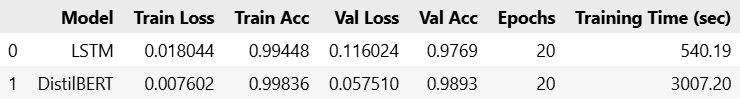

In [14]:
# --- Comparison ---
if TRAINING:
    results = pd.DataFrame(
        {
            "Model": ["LSTM", "DistilBERT"],
            "Train Loss": [
                lstm_history["train_loss"][-1],
                distilbert_history["train_loss"][-1],
            ],
            "Train Acc": [
                lstm_history["train_acc"][-1],
                distilbert_history["train_acc"][-1],
            ],
            "Val Loss": [lstm_history["val_loss"][-1], distilbert_history["val_loss"][-1]],
            "Val Acc": [lstm_history["val_acc"][-1], distilbert_history["val_acc"][-1]],
            "Epochs": [epochs_to_run, epochs_to_run],
            "Training Time (sec)": [round(lstm_time, 2), round(distilbert_time, 2)],
        }
    )
    results
else:
    display(Image.open("comparison.png"))